In [13]:
import numpy as np
import matplotlib.pyplot as plt


In [14]:
def load_dataset():
    """
    Load the Iris dataset from a CSV file.

    Returns:
        tuple: A tuple containing:
            - X (np.ndarray): The feature matrix of shape (4, n_samples).
            - y (np.ndarray): The label vector of shape (n_samples,).
    """
    path = '../lab_2/iris.csv'
    data = []
    with open(path, 'r') as f:
        for line in f:
            data.append(line.strip().split(','))
    mapping = {'Iris-setosa': 0, 'Iris-versicolor': 1, 'Iris-virginica': 2}
    X, y = [], []
    for d in data:
        X.append(list(map(float, d[:4])))
        y.append(mapping[d[4]])
    return np.array(X).T, np.array(y)

X, y = load_dataset()
print(X, y)


[[5.1 4.9 4.7 4.6 5.  5.4 4.6 5.  4.4 4.9 5.4 4.8 4.8 4.3 5.8 5.7 5.4 5.1
  5.7 5.1 5.4 5.1 4.6 5.1 4.8 5.  5.  5.2 5.2 4.7 4.8 5.4 5.2 5.5 4.9 5.
  5.5 4.9 4.4 5.1 5.  4.5 4.4 5.  5.1 4.8 5.1 4.6 5.3 5.  7.  6.4 6.9 5.5
  6.5 5.7 6.3 4.9 6.6 5.2 5.  5.9 6.  6.1 5.6 6.7 5.6 5.8 6.2 5.6 5.9 6.1
  6.3 6.1 6.4 6.6 6.8 6.7 6.  5.7 5.5 5.5 5.8 6.  5.4 6.  6.7 6.3 5.6 5.5
  5.5 6.1 5.8 5.  5.6 5.7 5.7 6.2 5.1 5.7 6.3 5.8 7.1 6.3 6.5 7.6 4.9 7.3
  6.7 7.2 6.5 6.4 6.8 5.7 5.8 6.4 6.5 7.7 7.7 6.  6.9 5.6 7.7 6.3 6.7 7.2
  6.2 6.1 6.4 7.2 7.4 7.9 6.4 6.3 6.1 7.7 6.3 6.4 6.  6.9 6.7 6.9 5.8 6.8
  6.7 6.7 6.3 6.5 6.2 5.9]
 [3.5 3.  3.2 3.1 3.6 3.9 3.4 3.4 2.9 3.1 3.7 3.4 3.  3.  4.  4.4 3.9 3.5
  3.8 3.8 3.4 3.7 3.6 3.3 3.4 3.  3.4 3.5 3.4 3.2 3.1 3.4 4.1 4.2 3.1 3.2
  3.5 3.6 3.  3.4 3.5 2.3 3.2 3.5 3.8 3.  3.8 3.2 3.7 3.3 3.2 3.2 3.1 2.3
  2.8 2.8 3.3 2.4 2.9 2.7 2.  3.  2.2 2.9 2.9 3.1 3.  2.7 2.2 2.5 3.2 2.8
  2.5 2.8 2.9 3.  2.8 3.  2.9 2.6 2.4 2.4 2.7 2.7 3.  3.4 3.1 2.3 3.  2.5
  2.6 3.  2.

In [15]:
def dataset_mean(X):
    """
    Calculate the mean of the dataset.

    Args:
        X (np.ndarray): The feature matrix of shape (4, n_samples).

    Returns:
        np.ndarray: The mean vector of shape (4,).
    """
    return X.mean(1)

mu = dataset_mean(X)
print(mu)


[5.84333333 3.05733333 3.758      1.19933333]


In [16]:
def center_dataset(X):
    """
    Center the dataset by subtracting the mean.

    Args:
        X (np.ndarray): The feature matrix of shape (4, n_samples).

    Returns:
        np.ndarray: The centered feature matrix of shape (4, n_samples).
    """
    return X - X.mean(1).reshape(-1, 1)

Xc = center_dataset(X)


In [17]:
def dataset_covariance_matrix(X, Xc):
    """
    Compute the covariance matrix of the dataset.

    Args:
        X (np.ndarray): The original feature matrix of shape (4, n_samples).
        Xc (np.ndarray): The centered feature matrix of shape (4, n_samples).

    Returns:
        np.ndarray: The covariance matrix of shape (4, 4).
    """
    return (Xc @ Xc.T) / float(Xc.shape[1])

cov = dataset_covariance_matrix(X, Xc)
print(cov)


[[ 0.68112222 -0.04215111  1.26582     0.51282889]
 [-0.04215111  0.18871289 -0.32745867 -0.12082844]
 [ 1.26582    -0.32745867  3.09550267  1.286972  ]
 [ 0.51282889 -0.12082844  1.286972    0.57713289]]


In [18]:
def dataset_eigen_decomposition(cov):
    """
    Perform eigen decomposition on the covariance matrix.

    Args:
        cov (np.ndarray): The covariance matrix of shape (4, 4).

    Returns:
        tuple: A tuple containing:
            - s (np.ndarray): The eigenvalues of shape (4,).
            - U (np.ndarray): The eigenvectors of shape (4, 4).
    """
    return np.linalg.eig(cov)

s, U = dataset_eigen_decomposition(cov)
print(s)
print(U)


[4.20005343 0.24105294 0.0776881  0.02367619]
[[ 0.36138659 -0.65658877 -0.58202985  0.31548719]
 [-0.08452251 -0.73016143  0.59791083 -0.3197231 ]
 [ 0.85667061  0.17337266  0.07623608 -0.47983899]
 [ 0.3582892   0.07548102  0.54583143  0.75365743]]


In [19]:
def top_m_eigenvectors(U, m):
    """
    Select the top m eigenvectors.

    Args:
        U (np.ndarray): The eigenvector matrix of shape (4, 4).
        m (int): The number of top eigenvectors to select.

    Returns:
        np.ndarray: The matrix of top m eigenvectors of shape (4, m).
    """
    return U[:, ::-1][:, :m][:, ::-1]

m = 4
P = top_m_eigenvectors(U, m)
print(P)


[[ 0.36138659 -0.65658877 -0.58202985  0.31548719]
 [-0.08452251 -0.73016143  0.59791083 -0.3197231 ]
 [ 0.85667061  0.17337266  0.07623608 -0.47983899]
 [ 0.3582892   0.07548102  0.54583143  0.75365743]]


In [20]:
def project_dataset(X, P):
    """
    Project the dataset onto the top m eigenvectors.

    Args:
        X (np.ndarray): The original feature matrix of shape (4, n_samples).
        P (np.ndarray): The matrix of top m eigenvectors of shape (4, m).

    Returns:
        np.ndarray: The projected dataset of shape (m, n_samples).
    """
    return P.T @ X

Xp = project_dataset(X, P)
print(Xp)


[[ 2.81823951e+00  2.78822345e+00  2.61337456e+00  2.75702228e+00
   2.77364860e+00  3.22150550e+00  2.68182738e+00  2.87622016e+00
   2.61598240e+00  2.82960933e+00  2.99541804e+00  2.88960990e+00
   2.71625587e+00  2.27856139e+00  2.85761474e+00  3.11632610e+00
   2.87883726e+00  2.85406843e+00  3.30254481e+00  2.91437873e+00
   3.19210892e+00  2.95865990e+00  2.28642572e+00  3.19963195e+00
   3.14661108e+00  2.99569623e+00  3.03354506e+00  2.94004523e+00
   2.86283042e+00  2.87037575e+00  2.91496666e+00  3.09243264e+00
   2.85350280e+00  2.90362838e+00  2.86543825e+00  2.63612348e+00
   2.87712708e+00  2.70168102e+00  2.52186309e+00  2.91235882e+00
   2.73226271e+00  2.65299643e+00  2.50495859e+00  3.09675065e+00
   3.29287589e+00  2.78791371e+00  2.96421687e+00  2.66290296e+00
   2.95927938e+00  2.79900535e+00  6.78719082e+00  6.43485366e+00
   6.96666745e+00  5.68568285e+00  6.59046839e+00  6.14403422e+00
   6.59742580e+00  4.75324246e+00  6.54649696e+00  5.49361973e+00
   4.99452

In [21]:
solution = np.load('IRIS_PCA_matrix_m4.npy')
print(solution)


[[-0.36138659  0.65658877  0.58202985  0.31548719]
 [ 0.08452251  0.73016143 -0.59791083 -0.3197231 ]
 [-0.85667061 -0.17337266 -0.07623608 -0.47983899]
 [-0.3582892  -0.07548102 -0.54583143  0.75365743]]


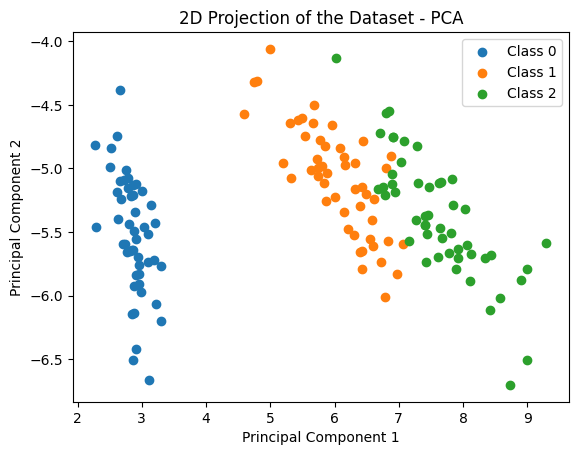

In [22]:
def plot_projected_dataset(Xp, y):
    """
    Plot the 2D projection of the dataset.

    Args:
        Xp (np.ndarray): The projected dataset of shape (2, n_samples).
        y (np.ndarray): The label vector of shape (n_samples,).
    """
    for label in np.unique(y):
        plt.scatter(Xp[0, y == label], Xp[1, y == label], label=f'Class {label}')
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.title('2D Projection of the Dataset - PCA')
    plt.legend()
    plt.show()

plot_projected_dataset(Xp, y)

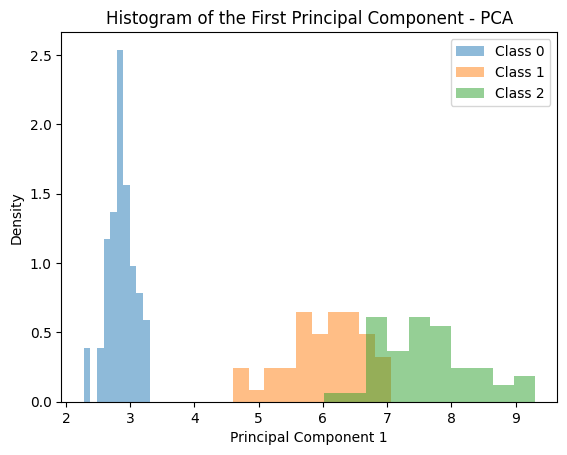

In [23]:
def plot_hist_first(Xp, y):
    """
    Plot the histogram of the first principal component.

    Args:
        Xp (np.ndarray): The projected dataset of shape (2, n_samples).
        y (np.ndarray): The label vector of shape (n_samples,).
    """
    plt.figure()
    for l in np.unique(y):
        plt.hist(Xp[0, y == l], label=f'Class {l}', alpha=0.5, bins=10, density=True)
    plt.xlabel('Principal Component 1')
    plt.ylabel('Density')
    plt.title('Histogram of the First Principal Component - PCA')
    plt.legend()
    plt.show()

plot_hist_first(Xp, y)